# Module 10 Lab - Unsupervised Learning**Objective:** To understand and apply two common **unsupervised learning** techniques: **K-Means Clustering** for finding groups in data and **Principal Component Analysis (PCA)** for dimensionality reduction.**In this lab, you will write the code to perform clustering and PCA, and you will interpret the results.**

## Part 1: Supervised vs. Unsupervised LearningSo far, every model we have built has been a **supervised learning** model. This means we had **labeled data**—we had both the features (X) and the correct answer, or target (y). The goal was to learn a mapping from X to y.In **unsupervised learning**, we only have the features (X). There is **no target variable**. The goal is to discover interesting structures or patterns hidden in the data on its own.Two major types of unsupervised learning are:*   **Clustering:** Automatically grouping similar data points together.*   **Dimensionality Reduction:** Compressing the data by reducing the number of features while trying to preserve as much information as possible.

## Part 2: K-Means Clustering**Concept:** K-Means is an algorithm that finds a pre-defined number of clusters (`k`) in a dataset. It works by:1.  Randomly placing `k` centroids (the center of a cluster) in the data.2.  **Assignment Step:** Assigning each data point to its nearest centroid.3.  **Update Step:** Moving each centroid to the average position of all the points assigned to it.4.  Repeating steps 2 and 3 until the centroids stop moving.**Problem:** We will use a synthetic dataset of customer spending habits to segment them into groups.

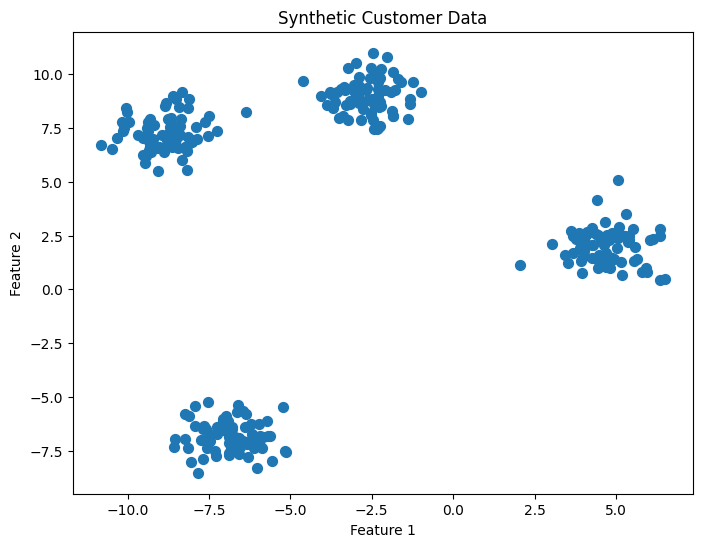

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate synthetic data
X, y = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

# Visualize the data
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    s=50
)

plt.title("Synthetic Customer Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

### Task 1: Find the Optimal Number of Clusters (The Elbow Method)**Concept:** How do we know what `k` should be? The **Elbow Method** helps us decide. We run K-Means for a range of `k` values and for each `k`, we calculate the **inertia** (the sum of squared distances of samples to their closest cluster center). We then plot the inertia for each `k`. The "elbow" of the curve—the point where the inertia starts to decrease much more slowly—is a good estimate for the optimal `k`.**Your Task:** Calculate and plot the inertia for `k` values from 1 to 10.

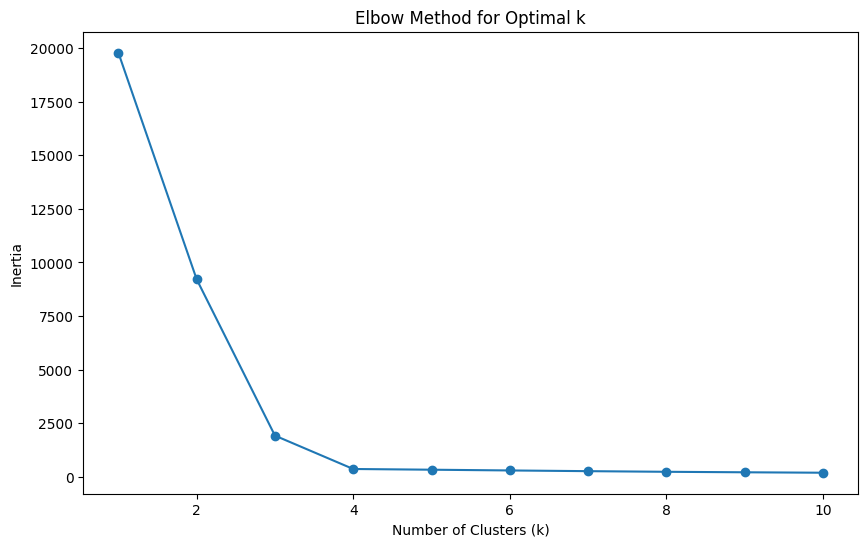

In [2]:
from sklearn.cluster import KMeans

# Store inertia values for each k
inertia = []

# Test K-Means with k values from 1 to 10
for k in range(1, 11):
    # Create and fit the K-Means model
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    # Store the inertia value for this k
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 11),
    inertia,
    marker='o'
)

plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.show()

### Task 2: Perform K-Means Clustering and VisualizeFrom the elbow plot, it looks like `k=4` is the optimal number of clusters.**Your Task:** Run K-Means with `n_clusters=4` and create a scatter plot showing the data points colored by their assigned cluster.

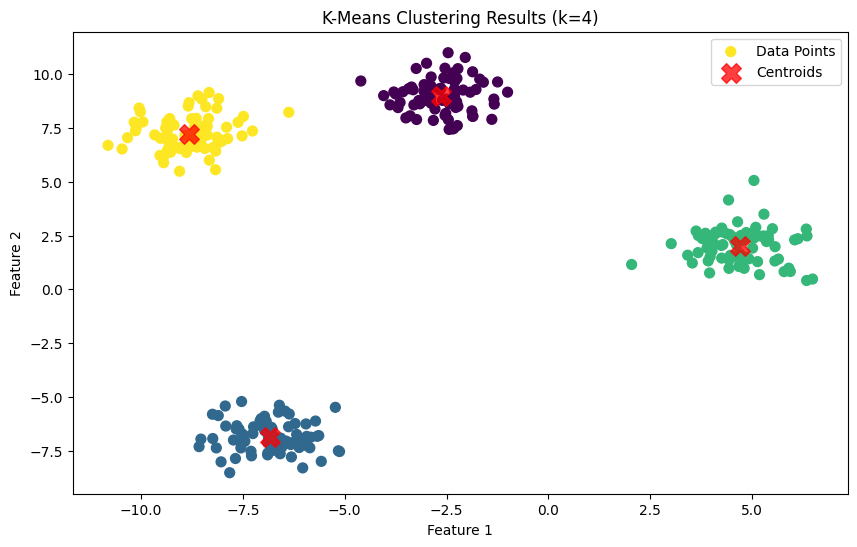

In [3]:
# Create and fit the K-Means model with the optimal number of clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

# Get the cluster assignments for each data point
labels = kmeans.labels_

# Get the coordinates of the cluster centers
centers = kmeans.cluster_centers_

# Visualize the clustering results
plt.figure(figsize=(10, 6))

# Plot data points colored by their assigned cluster
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    s=50,
    cmap="viridis",
    label="Data Points"
)

# Plot the cluster centers
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="red",
    s=200,
    alpha=0.75,
    marker="X",
    label="Centroids"
)

plt.title("K-Means Clustering Results (k=4)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.show()

## Part 3: Principal Component Analysis (PCA)**Concept:** PCA is a dimensionality reduction technique. It transforms the data into a new coordinate system of **principal components**. These components are orthogonal (uncorrelated) and are ordered by the amount of variance in the data they explain. By keeping only the first few principal components, we can reduce the number of dimensions in our data while losing as little information as possible.**Use Cases:***   **Visualization:** Reducing high-dimensional data to 2 or 3 dimensions so we can plot it.*   **Performance:** Speeding up model training by using fewer features.**Problem:** We will use the Iris dataset, which has 4 features, and reduce it to 2 features so we can visualize it.

### Task 3: Apply PCA to the Iris Dataset**Your Task:** Use `PCA` from `sklearn.decomposition` to reduce the 4-dimensional Iris dataset to 2 principal components and visualize the result.

Explained variance by component: [0.92461872 0.05306648]
Total variance explained by 2 components: 97.77%


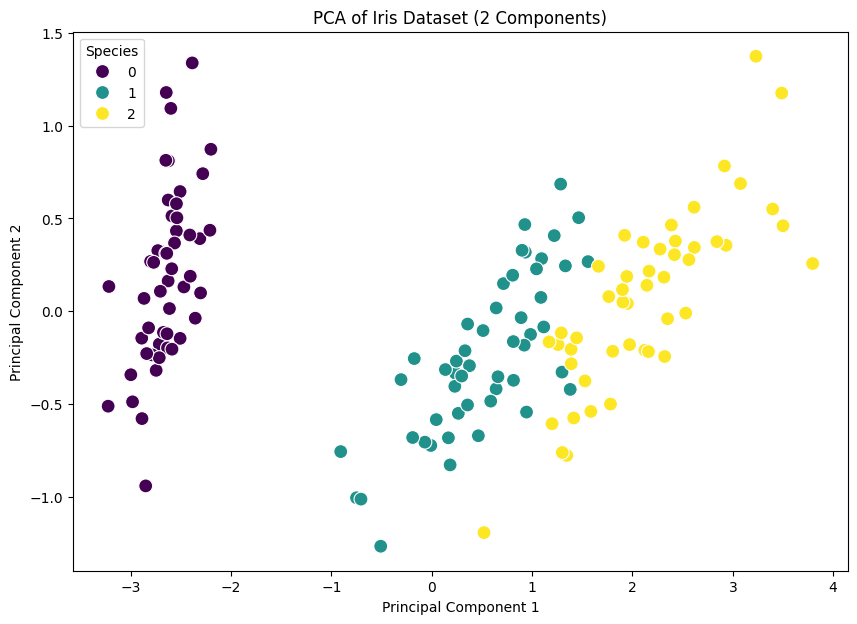

In [4]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris dataset
iris = load_iris()

X_iris = iris.data
y_iris = iris.target

# Create PCA instance to reduce data from 4 dimensions to 2 components
pca = PCA(n_components=2)

# Fit PCA and transform the data
X_pca = pca.fit_transform(X_iris)

# Display explained variance
print(f"Explained variance by component: {pca.explained_variance_ratio_}")
print(
    f"Total variance explained by 2 components: "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

# Create DataFrame for visualization
pca_df = pd.DataFrame(
    data=X_pca,
    columns=[
        "Principal Component 1",
        "Principal Component 2"
    ]
)

pca_df["Species"] = y_iris

# Visualize PCA results
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x="Principal Component 1",
    y="Principal Component 2",
    hue="Species",
    data=pca_df,
    palette="viridis",
    s=100
)

plt.title("PCA of Iris Dataset (2 Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

## 📝 Knowledge Check**Instructions:** Answer the following questions in this markdown cell.1.  **What is the fundamental difference between supervised and unsupervised learning?**2.  **In the K-Means elbow plot, why don't we just choose the largest possible `k` to get the lowest inertia?**3.  **In the PCA results, the first two principal components explained over 95% of the variance. What does this tell you about the original 4-dimensional Iris dataset?



1.   Supervised learning uses labeled data (X: features, y: target) for inference prediction,such as classification or regression. Unsupervised learning only uses the input features (X) to discover hidden patterns or structures in the data. In our K-Means example, the algorithm only used synthetic customer features (X) and discovered clusters without being given the correct labels (y).
2.   It may seem counterintuitive, but too many clusters can  actually lead to overfitting and meaningless groupings. This is because increasing k will always decrease inertia because more clusters allow the model to fit the data more closely. The elbow method mitigates against this issue by helping the user find the balance between reducing error and keeping clusters interpretable. The user chooses the point where additional clusters provide only small improvements.
3. The PCA results tell me that most of the important information in the original four Iris features can be represented in just two dimensions. The features contain strong relationships/correlations, allowing PCA to reduce dimensionality while preserving most of the dataset's structure.